# LOREM-sog-cu30-lr-mp1-run2：每个 epoch 等变电荷与 SR/LR 能量分析

本 notebook 分析目录 `run/diagnostics/` 下的 `step_*_equivariant_charges.csv`：
- 每个 epoch 前 20 个原子的等变电荷（单极/偶极/四极）
- 每个 epoch 前 20 个原子的短程/长程能量
- 以上量随 epoch 的变化曲线


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True


In [2]:
WORKDIR = Path('/data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-sog-cu30-lr-mp1-run2')
DIAG_DIR = WORKDIR / 'run' / 'diagnostics'
CFG = WORKDIR / 'run' / 'checkpoints' / 'R2_E+F' / 'config.yaml'

assert DIAG_DIR.exists(), f'诊断目录不存在: {DIAG_DIR}'
assert CFG.exists(), f'配置文件不存在: {CFG}'

diag_files = sorted(DIAG_DIR.glob('step_*_equivariant_charges.csv'))
print('diagnostic files:', len(diag_files))
print('first:', diag_files[0].name if diag_files else None)
print('last :', diag_files[-1].name if diag_files else None)


diagnostic files: 998
first: step_00004005_equivariant_charges.csv
last : step_03996990_equivariant_charges.csv


In [3]:
# 从 config.yaml 读 n_train，用于 step -> epoch 映射
n_train = None
with open(CFG, 'r') as f:
    for line in f:
        if line.strip().startswith('n_train:'):
            n_train = int(line.split(':', 1)[1].strip())
            break
if n_train is None:
    n_train = 2000  # fallback

print('n_train =', n_train)

step_re = re.compile(r'step_(\d+)_equivariant_charges\.csv')

def step_from_name(path: Path) -> int:
    m = step_re.match(path.name)
    if m is None:
        raise ValueError(f'Unexpected diagnostics filename: {path.name}')
    return int(m.group(1))


n_train = 2000


In [4]:
# 读取每个 step 的前20原子电荷与能量
rows = []
for f in diag_files:
    step = step_from_name(f)
    epoch = step / n_train
    d = pd.read_csv(f)
    d = d.sort_values('atom_index').head(20).copy()

    # 列映射：
    # scalar_charge -> q0
    # sph_1,sph_2,sph_3 -> q1 (3分量)
    # sph_4..sph_8 -> q2 (5分量)
    d['step'] = step
    d['epoch_est'] = epoch
    d['q0'] = d['scalar_charge']
    d['q1_x'] = d['sph_1']
    d['q1_y'] = d['sph_2']
    d['q1_z'] = d['sph_3']
    d['q1_norm'] = np.sqrt(d['q1_x']**2 + d['q1_y']**2 + d['q1_z']**2)
    d['q2_0'] = d['sph_4']
    d['q2_1'] = d['sph_5']
    d['q2_2'] = d['sph_6']
    d['q2_3'] = d['sph_7']
    d['q2_4'] = d['sph_8']
    d['q2_norm'] = np.sqrt(d[['q2_0','q2_1','q2_2','q2_3','q2_4']].pow(2).sum(axis=1))

    keep = [
        'step', 'epoch_est', 'atom_index', 'Z',
        'q0', 'q1_x', 'q1_y', 'q1_z', 'q1_norm',
        'q2_0', 'q2_1', 'q2_2', 'q2_3', 'q2_4', 'q2_norm',
        'energy_short', 'energy_long'
    ]
    rows.append(d[keep])

top20_df = pd.concat(rows, ignore_index=True)
top20_df.head(30)


,step,epoch_est,atom_index,Z,q0,q1_x,q1_y,q1_z,q1_norm,q2_0,q2_1,q2_2,q2_3,q2_4,q2_norm,energy_short,energy_long
0,4005,2.0025,0.0,6.0,0.446293,-0.000025,-0.002520,-0.000379,0.002548,0.003409,-2.922494e-03,4.300097e-03,0.001157,-0.003133,0.007057,-0.256771,0.224151
1,4005,2.0025,1.0,1.0,-0.508858,-0.000028,0.000046,0.000009,0.000055,0.000047,9.609263e-06,7.570871e-05,0.000018,-0.000012,0.000092,-0.069808,0.178087
2,4005,2.0025,2.0,1.0,-0.495256,0.000038,0.000005,0.000021,0.000044,-0.000007,-5.013769e-05,-2.538383e-06,0.000013,-0.000033,0.000062,-0.122430,0.172309
3,4005,2.0025,3.0,6.0,0.424472,0.001476,0.004124,0.004458,0.006250,0.013243,4.925239e-04,3.848773e-04,-0.011483,0.003400,0.017866,0.273064,0.270423
4,4005,2.0025,4.0,6.0,0.390574,0.002171,-0.002458,0.001079,0.003452,0.005873,1.958894e-03,1.949233e-03,-0.003587,0.004832,0.008851,-0.417493,0.230665
5,4005,2.0025,5.0,6.0,0.382388,0.000167,0.002017,0.001047,0.002279,0.005572,6.334072e-03,1.236032e-03,0.001508,0.004317,0.009675,-0.399233,0.230907
6,4005,2.0025,6.0,6.0,0.360699,0.000272,0.000481,0.001305,0.001417,0.004982,8.849786e-03,9.612933e-05,0.001515,0.006756,0.012292,-0.438842,0.225995
7,4005,2.0025,7.0,6.0,0.362605,0.000817,-0.001874,0.000892,0.002230,0.006080,7.410788e-03,-1.845764e-03,0.001671,0.006709,0.011962,-0.545104,0.220301
8,4005,2.0025,8.0,6.0,0.356682,-0.000008,0.000491,0.001132,0.001234,0.004634,7.153418e-03,-2.535200e-03,0.007561,0.003905,0.012308,-0.598351,0.217022
9,4005,2.0025,9.0,6.0,0.394302,0.001174,-0.000688,0.001647,0.002137,0.005997,1.231979e-02,-7.887726e-03,0.011226,0.003370,0.019681,-0.218952,0.241162


In [5]:
# 导出“每个epoch前20原子”的完整表
out_csv = WORKDIR / 'epoch_top20_equivariant_charges_and_energies.csv'
top20_df.to_csv(out_csv, index=False)
print('saved:', out_csv)
print('rows:', len(top20_df), ', epochs:', top20_df['step'].nunique())


saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-sog-cu30-lr-mp1-run2/epoch_top20_equivariant_charges_and_energies.csv
rows: 12974 , epochs: 998


In [6]:
# 每个epoch聚合统计（用于曲线与对比）
# 说明：当前这个 diagnostics csv 里通常没有逐原子的 F_long / F_total 列，
# 因此该比值只有在相关列存在时才会计算；否则填 NaN。
agg_spec = {
    'q0_mean': ('q0', 'mean'),
    'q0_std': ('q0', 'std'),
    'q0_abs_mean': ('q0', lambda x: np.mean(np.abs(x))),
    'q1_norm_mean': ('q1_norm', 'mean'),
    'q1_norm_std': ('q1_norm', 'std'),
    'q2_norm_mean': ('q2_norm', 'mean'),
    'q2_norm_std': ('q2_norm', 'std'),
    'sr_energy_sum': ('energy_short', 'sum'),
    'sr_energy_mean': ('energy_short', 'mean'),
    'lr_energy_sum': ('energy_long', 'sum'),
    'lr_energy_mean': ('energy_long', 'mean'),
}

force_long_candidates = ['force_long_norm', 'f_long_norm', 'F_long_norm']
force_total_candidates = ['force_total_norm', 'f_total_norm', 'F_total_norm']

f_long_col = next((c for c in force_long_candidates if c in top20_df.columns), None)
f_total_col = next((c for c in force_total_candidates if c in top20_df.columns), None)

if f_long_col is not None and f_total_col is not None:
    agg_spec['f_long_sum'] = (f_long_col, 'sum')
    agg_spec['f_total_sum'] = (f_total_col, 'sum')

epoch_stats = (
    top20_df.groupby(['step', 'epoch_est'], as_index=False)
    .agg(**agg_spec)
    .sort_values('step')
    .reset_index(drop=True)
)

eps = 1e-12
epoch_stats['e_total_sum'] = epoch_stats['sr_energy_sum'] + epoch_stats['lr_energy_sum']
epoch_stats['e_long_over_e_total'] = epoch_stats['lr_energy_sum'] / np.maximum(np.abs(epoch_stats['e_total_sum']), eps)

if 'f_long_sum' in epoch_stats.columns and 'f_total_sum' in epoch_stats.columns:
    epoch_stats['f_long_over_f_total'] = epoch_stats['f_long_sum'] / np.maximum(epoch_stats['f_total_sum'], eps)
else:
    epoch_stats['f_long_over_f_total'] = np.nan
    print('提示：当前数据文件不含逐原子 F_long/F_total 列，f_long_over_f_total 记为 NaN。')

pd.set_option('display.max_columns', None)
print('epoch_stats 所有列：')
print(epoch_stats.columns.tolist())

epoch_stats


提示：当前数据文件不含逐原子 F_long/F_total 列，f_long_over_f_total 记为 NaN。
epoch_stats 所有列：
['step', 'epoch_est', 'q0_mean', 'q0_std', 'q0_abs_mean', 'q1_norm_mean', 'q1_norm_std', 'q2_norm_mean', 'q2_norm_std', 'sr_energy_sum', 'sr_energy_mean', 'lr_energy_sum', 'lr_energy_mean', 'e_total_sum', 'e_long_over_e_total', 'f_long_over_f_total']


,step,epoch_est,q0_mean,q0_std,q0_abs_mean,q1_norm_mean,q1_norm_std,q2_norm_mean,q2_norm_std,sr_energy_sum,sr_energy_mean,lr_energy_sum,lr_energy_mean,e_total_sum,e_long_over_e_total,f_long_over_f_total
0,4005,2.0025,0.117916,0.440247,0.434590,0.002142,0.002121,0.008249,0.006729,-2.680023,-0.206156,2.826585,0.217430,0.146562,19.285949,NaN
1,8010,4.0050,0.273268,0.037267,0.273268,0.014489,0.018584,0.078432,0.078989,-1.903299,-0.146408,1.701108,0.130854,-0.202191,8.413376,NaN
2,12015,6.0075,0.122408,0.169658,0.128433,0.065125,0.087536,0.176791,0.240442,-1.324592,-0.101892,1.729806,0.133062,0.405214,4.268873,NaN
3,16020,8.0100,0.304960,0.538447,0.359083,0.162711,0.254419,0.231943,0.362821,-1.242919,-0.095609,1.470733,0.113133,0.227814,6.455854,NaN
4,20025,10.0125,0.205342,0.165010,0.205342,0.221535,0.338026,0.282559,0.416590,-1.396134,-0.107395,1.776278,0.136637,0.380144,4.672644,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,3980970,1990.4850,0.041948,0.790145,0.684617,0.190285,0.386639,0.242223,0.483306,-2.845552,-0.218889,3.037497,0.233654,0.191945,15.824813,NaN
994,3984975,1992.4875,0.042246,0.790673,0.684970,0.190149,0.386542,0.241978,0.482800,-2.844106,-0.218777,3.037399,0.233646,0.193293,15.713928,NaN
995,3988980,1994.4900,0.042417,0.790862,0.685072,0.190310,0.386656,0.242177,0.483439,-2.824035,-0.217233,3.037604,0.233662,0.213569,14.223062,NaN
996,3992985,1996.4925,0.042302,0.790158,0.684492,0.190699,0.387296,0.242670,0.484157,-2.853651,-0.219512,3.036048,0.233542,0.182397,16.645285,NaN


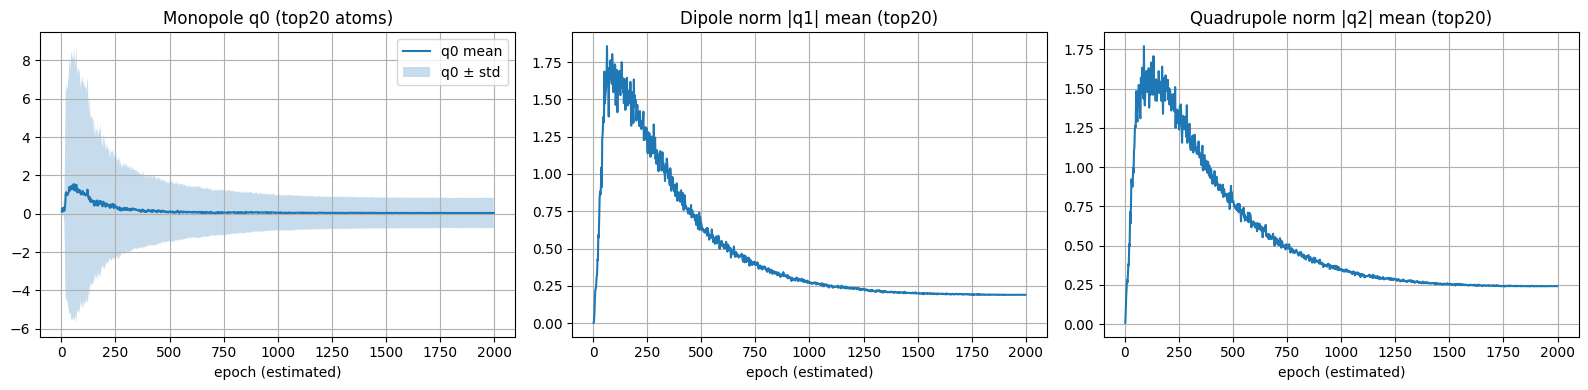

In [7]:
# 曲线1：电荷统计随epoch变化
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

axes[0].plot(epoch_stats['epoch_est'], epoch_stats['q0_mean'], label='q0 mean')
axes[0].fill_between(
    epoch_stats['epoch_est'],
    epoch_stats['q0_mean'] - epoch_stats['q0_std'].fillna(0),
    epoch_stats['q0_mean'] + epoch_stats['q0_std'].fillna(0),
    alpha=0.25,
    label='q0 ± std'
)
axes[0].set_title('Monopole q0 (top20 atoms)')
axes[0].set_xlabel('epoch (estimated)')
axes[0].legend()

axes[1].plot(epoch_stats['epoch_est'], epoch_stats['q1_norm_mean'])
axes[1].set_title('Dipole norm |q1| mean (top20)')
axes[1].set_xlabel('epoch (estimated)')

axes[2].plot(epoch_stats['epoch_est'], epoch_stats['q2_norm_mean'])
axes[2].set_title('Quadrupole norm |q2| mean (top20)')
axes[2].set_xlabel('epoch (estimated)')

plt.tight_layout()
plt.show()


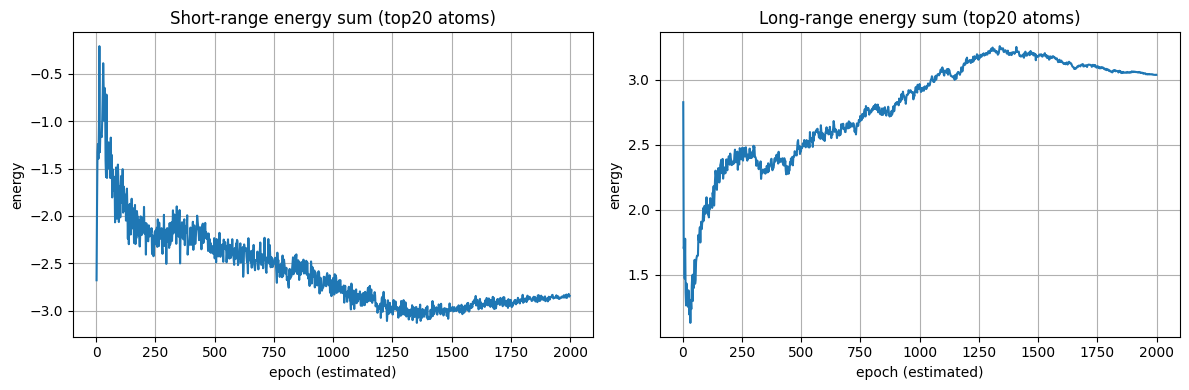

In [8]:
# 曲线2：短程/长程能量随epoch变化
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(epoch_stats['epoch_est'], epoch_stats['sr_energy_sum'])
axes[0].set_title('Short-range energy sum (top20 atoms)')
axes[0].set_xlabel('epoch (estimated)')
axes[0].set_ylabel('energy')

axes[1].plot(epoch_stats['epoch_est'], epoch_stats['lr_energy_sum'])
axes[1].set_title('Long-range energy sum (top20 atoms)')
axes[1].set_xlabel('epoch (estimated)')
axes[1].set_ylabel('energy')

plt.tight_layout()
plt.show()


In [9]:
# 单独查看某个epoch（前20原子详细值）
target_step = int(epoch_stats['step'].iloc[-1])  # 默认最后一个
view_df = top20_df[top20_df['step'] == target_step].copy().sort_values('atom_index')
print('target_step =', target_step, ', epoch_est =', float(view_df['epoch_est'].iloc[0]))
display(view_df)


target_step = 3996990 , epoch_est = 1998.495


,step,epoch_est,atom_index,Z,q0,q1_x,q1_y,q1_z,q1_norm,q2_0,q2_1,q2_2,q2_3,q2_4,q2_norm,energy_short,energy_long
12961,3996990,1998.495,0.0,6.0,-0.464790,-0.006821,0.893802,0.547778,1.048327,0.647174,-0.488962,0.836233,0.284159,-0.560420,1.323639,-1.212674,0.060623
12962,3996990,1998.495,1.0,1.0,1.181377,-0.000585,0.004982,0.001585,0.005261,-0.010831,0.007361,-0.008616,0.002974,0.006320,0.017162,0.896110,0.185194
12963,3996990,1998.495,2.0,1.0,1.182617,-0.000334,0.004811,0.001507,0.005053,-0.011333,0.008034,-0.007324,0.003859,0.006617,0.017473,0.892389,0.182507
12964,3996990,1998.495,3.0,6.0,-0.463967,-0.034935,0.138948,0.027635,0.145913,-0.001849,0.034176,0.017663,0.000495,0.024680,0.045746,-0.672358,0.385250
12965,3996990,1998.495,4.0,6.0,-0.463516,0.006290,-0.000210,0.000122,0.006295,0.050096,0.036024,-0.030081,-0.037051,0.013735,0.079206,-0.401816,0.201640
12966,3996990,1998.495,5.0,6.0,-0.463602,0.008336,0.008874,0.008818,0.015033,0.048336,0.040792,-0.032061,-0.014792,0.017691,0.074566,-0.445090,0.227270
12967,3996990,1998.495,6.0,6.0,-0.463911,0.002075,-0.002259,0.005278,0.006104,0.034491,0.019786,0.001853,0.013500,0.032808,0.053321,-0.662808,0.215108
12968,3996990,1998.495,7.0,6.0,-0.463901,-0.008677,0.004133,0.013365,0.016462,0.036092,0.048301,-0.015421,0.016944,0.002638,0.064556,-0.632723,0.329772
12969,3996990,1998.495,8.0,6.0,-0.463936,0.003282,0.004318,0.013641,0.014680,0.039146,0.046611,-0.012872,0.014264,0.003120,0.063905,-0.636112,0.317424
12970,3996990,1998.495,9.0,6.0,-0.464106,0.047490,-0.121287,0.046116,0.138176,0.009227,-0.009878,0.014312,0.022691,0.006152,0.030663,-0.833907,0.372528


In [10]:
# 保存聚合曲线数据
epoch_csv = WORKDIR / 'epoch_top20_charge_energy_curves.csv'
epoch_stats.to_csv(epoch_csv, index=False)
print('saved:', epoch_csv)
epoch_stats.tail()


saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-sog-cu30-lr-mp1-run2/epoch_top20_charge_energy_curves.csv


,step,epoch_est,q0_mean,q0_std,q0_abs_mean,q1_norm_mean,q1_norm_std,q2_norm_mean,q2_norm_std,sr_energy_sum,sr_energy_mean,lr_energy_sum,lr_energy_mean,e_total_sum,e_long_over_e_total,f_long_over_f_total
993,3980970,1990.4850,0.041948,0.790145,0.684617,0.190285,0.386639,0.242223,0.483306,-2.845552,-0.218889,3.037497,0.233654,0.191945,15.824813,NaN
994,3984975,1992.4875,0.042246,0.790673,0.684970,0.190149,0.386542,0.241978,0.482800,-2.844106,-0.218777,3.037399,0.233646,0.193293,15.713928,NaN
995,3988980,1994.4900,0.042417,0.790862,0.685072,0.190310,0.386656,0.242177,0.483439,-2.824035,-0.217233,3.037604,0.233662,0.213569,14.223062,NaN
996,3992985,1996.4925,0.042302,0.790158,0.684492,0.190699,0.387296,0.242670,0.484157,-2.853651,-0.219512,3.036048,0.233542,0.182397,16.645285,NaN
997,3996990,1998.4950,0.042798,0.791198,0.685224,0.190362,0.386837,0.242307,0.483634,-2.844606,-0.218816,3.036984,0.233614,0.192379,15.786469,NaN


## 复现 cumulene 二面角能量曲线（参考 `results_cumulene.py`）

下面代码按 `experiments/results_cumulene.py` 的流程绘图：
- 横轴：二面角（按角度排序）
- 纵轴：相对势能（各自减去最小值）
- 两条曲线：预测能量 vs DFT 能量

优先使用当前目录已有的 `cumulene_dihedral_energy_curve.npz`；如果没有该文件，再尝试用 checkpoint 和 `cumulene_profile.xyz` 现场重算。

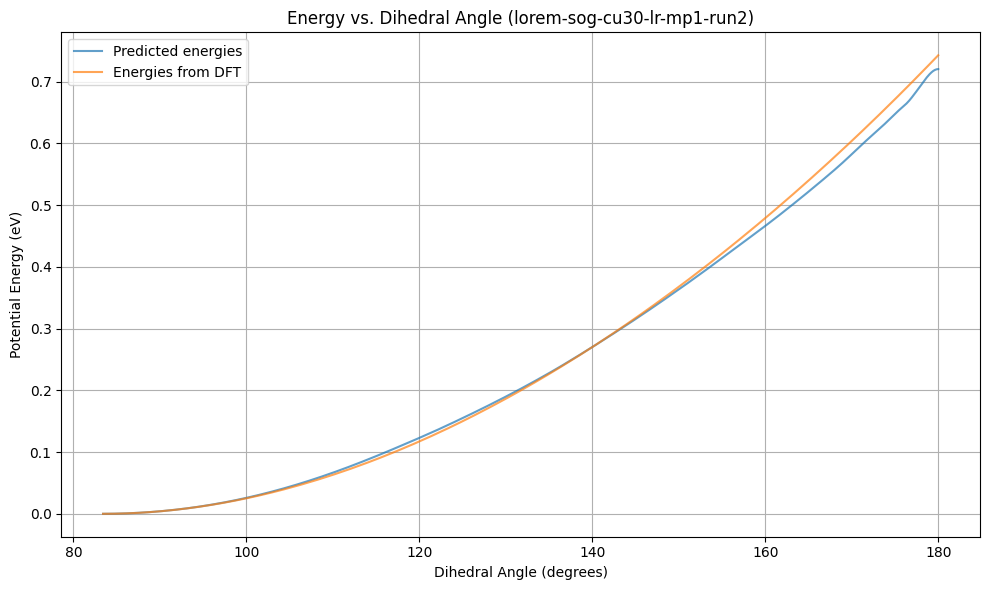

Saved plot to: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-sog-cu30-lr-mp1-run2/cumulene_dihedral_energy_curve_replot.png
Saved data to: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-sog-cu30-lr-mp1-run2/cumulene_dihedral_energy_curve_replot.npz


In [11]:
# 与 results_cumulene.py 一致风格：强制用 checkpoint + cumulene_profile.xyz 重算
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

workdir = Path('/data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-sog-cu30-lr-mp1-run2')
lorem_root = Path('/data/home/public/qiuqizhi/LOREM')
dataset_folder = lorem_root / 'datasets'
checkpoint_dir = workdir / 'run' / 'checkpoints' / 'R2_E+F'
out_path = workdir / 'cumulene_dihedral_energy_curve_replot.png'

# 使用 LOREM 原生 calculator
sys.path.insert(0, str(lorem_root / 'lorem'))
from calculator import Calculator


def assign_calculators(systems, calculator):
    for system in systems:
        system.calc = calculator


def order_by_dihedrals(systems, atom_indices=(0, 1, 11, 12)):
    dihedrals_local = np.array([sys.get_dihedral(*atom_indices) for sys in systems])
    order = np.argsort(dihedrals_local)
    systems[:] = [systems[i] for i in order]
    return dihedrals_local[order]


def get_energies(systems):
    energies = [sys.get_potential_energy() for sys in systems]
    min_e = min(energies)
    return np.array([e - min_e for e in energies])


xyz_path = dataset_folder / 'cumulene_profile.xyz'
assert xyz_path.exists(), f'数据文件不存在: {xyz_path}'
assert checkpoint_dir.exists(), f'checkpoint 不存在: {checkpoint_dir}'

systems = read(xyz_path, index=':')
dihedrals = order_by_dihedrals(systems)
actual_energies = get_energies(systems)

calc = Calculator.from_checkpoint(checkpoint_dir, add_offset=False)
assign_calculators(systems, calc)
predicted_energies = get_energies(systems)

# 按 results_cumulene.py 的绘图风格
plt.figure(figsize=(10, 6))
plt.plot(dihedrals, predicted_energies, label='Predicted energies', alpha=0.7)
plt.plot(dihedrals, actual_energies, label='Energies from DFT', alpha=0.7)
plt.xlabel('Dihedral Angle (degrees)')
plt.ylabel('Potential Energy (eV)')
plt.legend()
plt.title(f'Energy vs. Dihedral Angle ({workdir.stem})')
plt.tight_layout()
plt.savefig(out_path, dpi=200)
plt.show()

print('Saved plot to:', out_path)

# 保存本次重算数据
replot_npz = workdir / 'cumulene_dihedral_energy_curve_replot.npz'
np.savez(
    replot_npz,
    dihedrals=dihedrals,
    predicted_energies=predicted_energies,
    actual_energies=actual_energies,
)
print('Saved data to:', replot_npz)

## 用 checkpoint 预测时分解输出 short/long 能量

下面这段代码不是只拿 `Calculator.get_potential_energy()` 的总能量，而是像 `run.py` 的 `diagnostics_fn` 一样，调用模型 `apply(..., mutable=['intermediates'])`，读取：
- `diag_energy_short_raw`
- `diag_energy_long_raw`

然后对每个结构求和，得到每个二面角点的：
- `energy_total_pred`
- `energy_short_pred`
- `energy_long_pred`


saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-cu30-lr-mp1/cumulene_dihedral_energy_curve_split.csv
   dihedral_deg  actual_rel_e  pred_total_rel_e  pred_short_rel_e  \
0     83.424819      0.000000          0.000012          0.000003   
1     83.513758      0.000000          0.000012          0.000003   
2     83.602712      0.000008          0.000010          0.000003   
3     83.691682      0.000008          0.000008          0.000003   
4     83.780669      0.000015          0.000004          0.000002   

   pred_long_rel_e  pred_total_abs_e  pred_short_abs_e  pred_long_abs_e  
0         0.000011         -2.435923         -2.386389        -0.049534  
1         0.000010         -2.435923         -2.386389        -0.049534  
2         0.000008         -2.435925         -2.386389        -0.049536  
3         0.000006         -2.435927         -2.386389        -0.049539  
4         0.000004         -2.435931         -2.386390        -0.049541  


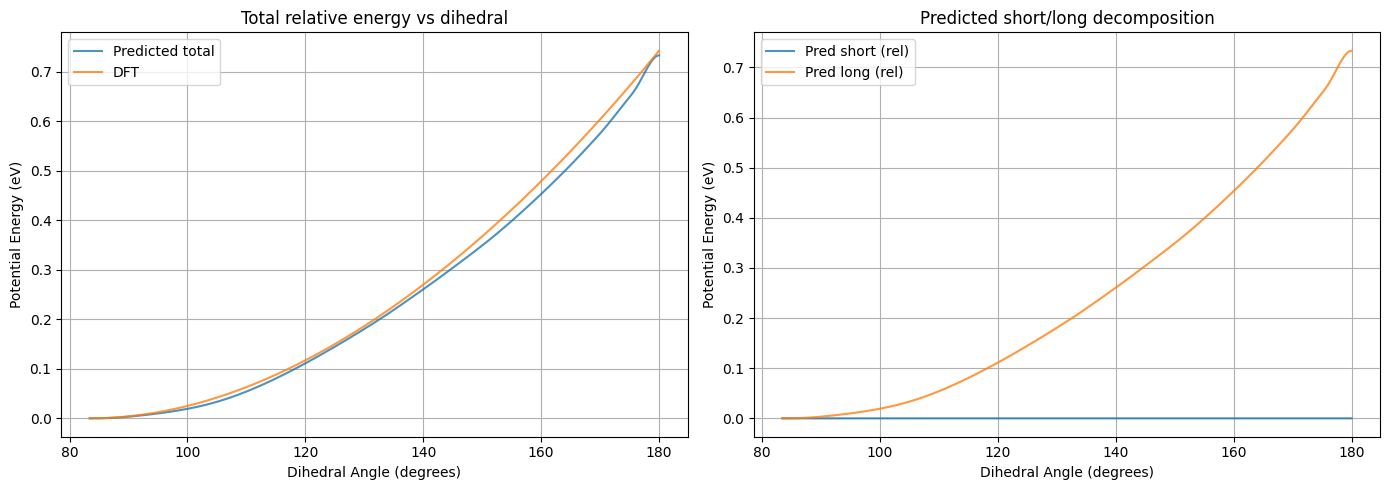

max |total - (short+long)| = 6.556510925292969e-07
long abs min/max = -0.04954478144645691 0.6838430166244507


In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from ase.io import read

import sys
lorem_src = '/data/home/public/qiuqizhi/LOREM/lorem'
if lorem_src not in sys.path:
    sys.path.insert(0, lorem_src)

from calculator import Calculator
from marathon.io import from_dict, read_yaml
from marathon.emit.checkpoint import read_msgpack

workdir = Path('/data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-cu30-lr-mp1')
dataset_folder = Path('/data/home/public/qiuqizhi/LOREM/datasets')
checkpoint_dir = workdir / 'run' / 'checkpoints' / 'R2_E+F'
xyz_path = dataset_folder / 'cumulene_profile.xyz'

assert checkpoint_dir.exists(), f'checkpoint not found: {checkpoint_dir}'
assert xyz_path.exists(), f'xyz not found: {xyz_path}'

# 1) 加载模型与参数（与 Calculator.from_checkpoint 的来源一致）
model = from_dict(read_yaml(checkpoint_dir / 'model' / 'model.yaml'))
_ = model.init(jax.random.key(1), *model.dummy_inputs())
params = read_msgpack(checkpoint_dir / 'model' / 'model.msgpack')

# 2) 准备系统并按二面角排序（与 results_cumulene.py 对齐）
systems = read(xyz_path, index=':')
dihedrals = np.array([sys.get_dihedral(0, 1, 11, 12) for sys in systems])
order = np.argsort(dihedrals)
systems = [systems[i] for i in order]
dihedrals = dihedrals[order]

# DFT 相对能量（参考）
actual = np.array([sys.get_potential_energy() for sys in systems], dtype=float)
actual = actual - actual.min()

# 3) 定义与 run.py 一致的诊断函数（提取 raw short/long）
@jax.jit
def diagnostics_fn(params, batch):
    energies, vars_out = model.apply(
        params,
        batch.edges,
        batch.centers,
        batch.others,
        batch.nodes,
        batch.edge_mask,
        batch.node_mask,
        batch.positions,
        batch.cell,
        batch.k_grid,
        batch.smearing,
        batch.full_edges,
        batch.full_centers,
        batch.full_others,
        batch.full_edge_mask,
        mutable=['intermediates'],
    )
    diag = vars_out['intermediates']
    node_mask = batch.node_mask

    e_total = jnp.sum(energies * node_mask)
    e_short = jnp.sum(diag['diag_energy_short_raw'][0] * node_mask)
    e_long = jnp.sum(diag['diag_energy_long_raw'][0] * node_mask)
    return e_total, e_short, e_long

# 4) 逐结构计算 total/short/long
calc = Calculator.from_checkpoint(checkpoint_dir, add_offset=False)

pred_total = []
pred_short = []
pred_long = []
for sys in systems:
    # 先触发 batch 构建
    calc.update(sys)
    batch = calc.batch

    e_total, e_short, e_long = diagnostics_fn(params, batch)
    pred_total.append(float(e_total))
    pred_short.append(float(e_short))
    pred_long.append(float(e_long))

pred_total = np.array(pred_total)
pred_short = np.array(pred_short)
pred_long = np.array(pred_long)

# 各自做相对能量（减最小值），便于曲线比较
pred_total_rel = pred_total - pred_total.min()
pred_short_rel = pred_short - pred_short.min()
pred_long_rel = pred_long - pred_long.min()

# 保存分解数据
split_df = pd.DataFrame({
    'dihedral_deg': dihedrals,
    'actual_rel_e': actual,
    'pred_total_rel_e': pred_total_rel,
    'pred_short_rel_e': pred_short_rel,
    'pred_long_rel_e': pred_long_rel,
    'pred_total_abs_e': pred_total,
    'pred_short_abs_e': pred_short,
    'pred_long_abs_e': pred_long,
})

split_csv = workdir / 'cumulene_dihedral_energy_curve_split.csv'
split_df.to_csv(split_csv, index=False)
print('saved:', split_csv)
print(split_df.head())

# 5) 画图：总能量对比 + short/long 分解
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(dihedrals, pred_total_rel, label='Predicted total', alpha=0.8)
axes[0].plot(dihedrals, actual, label='DFT', alpha=0.8)
axes[0].set_title('Total relative energy vs dihedral')
axes[0].set_xlabel('Dihedral Angle (degrees)')
axes[0].set_ylabel('Potential Energy (eV)')
axes[0].legend()

axes[1].plot(dihedrals, pred_short_rel, label='Pred short (rel)', alpha=0.8)
axes[1].plot(dihedrals, pred_long_rel, label='Pred long (rel)', alpha=0.8)
axes[1].set_title('Predicted short/long decomposition')
axes[1].set_xlabel('Dihedral Angle (degrees)')
axes[1].set_ylabel('Potential Energy (eV)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 一些快速检查量
print('max |total - (short+long)| =', np.max(np.abs(pred_total - (pred_short + pred_long))))
print('long abs min/max =', float(pred_long.min()), float(pred_long.max()))

## 导出每个构型的原子电荷信息（q0/q1/q2）

上面的 `cumulene_dihedral_energy_curve_split.csv` 是“每个二面角构型”的总能量分解。
如果需要看“每个原子”的电荷，这里额外导出：
- 标量电荷 `q0`
- 球谐电荷分量（按 `l=0,1,2` 切分）
- `q1_norm`、`q2_norm`

输出文件：`cumulene_dihedral_atom_charges.csv`。

In [ ]:
# 依赖上一段代码中的 model / params / systems / dihedrals / checkpoint_dir
# 如果你只想导出一部分构型或原子，可调下面两个参数
MAX_STRUCTURES = None          # 例如 50；None 表示全部构型
MAX_ATOMS_PER_STRUCTURE = None # 例如 20；None 表示全部原子

@jax.jit
def charge_diag_fn(params, batch):
    _, vars_out = model.apply(
        params,
        batch.edges,
        batch.centers,
        batch.others,
        batch.nodes,
        batch.edge_mask,
        batch.node_mask,
        batch.positions,
        batch.cell,
        batch.k_grid,
        batch.smearing,
        batch.full_edges,
        batch.full_centers,
        batch.full_others,
        batch.full_edge_mask,
        mutable=['intermediates'],
    )
    d = vars_out['intermediates']
    return (
        d['diag_scalar_charges_raw'][0],
        d['diag_spherical_charges_raw'][0],
        batch.node_mask,
        batch.nodes,
    )

calc = Calculator.from_checkpoint(checkpoint_dir, add_offset=False)

rows = []
num_structures = len(systems) if MAX_STRUCTURES is None else min(MAX_STRUCTURES, len(systems))

for i in range(num_structures):
    sys_i = systems[i]
    dih_i = float(dihedrals[i])

    calc.update(sys_i)
    batch = calc.batch

    scalar_raw, spherical_raw, node_mask, node_species = charge_diag_fn(params, batch)

    scalar_raw = np.asarray(scalar_raw)
    spherical_raw = np.asarray(spherical_raw)
    node_mask = np.asarray(node_mask).astype(bool)
    node_species = np.asarray(node_species)

    if node_species.ndim > 1:
        node_species = np.argmax(node_species, axis=-1)

    atom_idx = np.where(node_mask)[0]
    if MAX_ATOMS_PER_STRUCTURE is not None:
        atom_idx = atom_idx[:MAX_ATOMS_PER_STRUCTURE]

    for j in atom_idx:
        q0 = float(scalar_raw[j, 0])

        # spherical 按 l=0,1,2 切分（当前 max_degree_lr=2）
        # 宽度分别是 1,3,5，共 9 维
        sph = spherical_raw[j]
        q_l0 = sph[0:1]
        q_l1 = sph[1:4] if sph.shape[0] >= 4 else np.array([np.nan, np.nan, np.nan])
        q_l2 = sph[4:9] if sph.shape[0] >= 9 else np.array([np.nan] * 5)

        rows.append({
            'structure_index': i,
            'dihedral_deg': dih_i,
            'atom_index': int(j),
            'Z': int(node_species[j]),
            'q0': q0,
            'q_l0_0': float(q_l0[0]) if len(q_l0) > 0 else np.nan,
            'q_l1_0': float(q_l1[0]),
            'q_l1_1': float(q_l1[1]),
            'q_l1_2': float(q_l1[2]),
            'q_l1_norm': float(np.linalg.norm(q_l1)),
            'q_l2_0': float(q_l2[0]),
            'q_l2_1': float(q_l2[1]),
            'q_l2_2': float(q_l2[2]),
            'q_l2_3': float(q_l2[3]),
            'q_l2_4': float(q_l2[4]),
            'q_l2_norm': float(np.linalg.norm(q_l2)),
        })

charges_df = pd.DataFrame(rows)
charges_csv = workdir / 'cumulene_dihedral_atom_charges.csv'
charges_df.to_csv(charges_csv, index=False)

print('saved:', charges_csv)
print('shape:', charges_df.shape)
print('\n示例（前30行）:')
display(charges_df.head(30))

saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-cu30-lr-mp1/cumulene_dihedral_atom_charges.csv
shape: (13000, 16)

示例（前30行）:


,structure_index,dihedral_deg,atom_index,Z,q0,q_l0_0,q_l1_0,q_l1_1,q_l1_2,q_l1_norm,q_l2_0,q_l2_1,q_l2_2,q_l2_3,q_l2_4,q_l2_norm
0,0,83.424819,0,6,0.737282,-0.519433,-1.137710e+00,0.000000,0.00000,1.137710e+00,-1.093562,0.000000,0.000000,0.000000,-1.776513,2.086115
1,0,83.424819,1,1,-1.705932,0.002426,-4.911061e-03,0.001670,0.00000,5.187228e-03,0.013534,0.004287,0.000000,0.000000,0.012193,0.018714
2,0,83.424819,2,1,-1.705932,0.002426,-4.911062e-03,-0.001670,0.00000,5.187228e-03,0.013534,-0.004287,0.000000,0.000000,0.012193,0.018714
3,0,83.424819,3,6,0.699703,0.010882,-4.387366e-02,0.000000,0.00000,4.387366e-02,-0.002833,0.000000,0.000000,0.000000,0.045947,0.046034
4,0,83.424819,4,6,0.709371,0.003241,-1.631795e-03,0.000000,0.00000,1.631795e-03,-0.032574,0.000000,0.000000,0.000000,0.018807,0.037613
5,0,83.424819,5,6,0.711535,0.004524,1.551808e-04,0.000000,0.00000,1.551808e-04,-0.033257,0.000000,0.000000,0.000000,0.019201,0.038402
6,0,83.424819,6,6,0.711134,0.004367,-2.330622e-10,0.000000,0.00000,2.330622e-10,-0.033021,0.000000,0.000000,0.000000,0.019065,0.038130
7,0,83.424819,7,6,0.711535,0.004524,-1.551816e-04,0.000000,0.00000,1.551816e-04,-0.033257,0.000000,0.000000,0.000000,0.019201,0.038402
8,0,83.424819,8,6,0.709371,0.003241,1.631794e-03,0.000000,0.00000,1.631794e-03,-0.032574,0.000000,0.000000,0.000000,0.018807,0.037613
9,0,83.424819,9,6,0.699703,0.010882,4.387365e-02,0.000000,0.00000,4.387365e-02,-0.041207,0.000000,0.000000,0.000000,-0.020520,0.046034


: 